In [2]:
# importamos las librerías que necesitamos

# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np

# Visualización
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluar linealidad de las relaciones entre las variables
# ------------------------------------------------------------------------------
from scipy.stats import shapiro, kstest

# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames

# Gestión de los warnings
# -----------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

In [3]:
df_world = pd.read_csv("files/world_data_full_apply_nulos.csv", index_col=0)
df_world.head(2)

,country,density,abbreviation,agricultural_land,land_area,armed_forces_size,birth_rate,calling_code,capital/major_city,co2-emissions,cpi,cpi_change,currency-code,fertility_rate,forested_area,gasoline_price,gdp,gross_primary_education_enrollment,gross_tertiary_education_enrollment,infant_mortality,largest_city,life_expectancy,maternal_mortality_ratio,minimum_wage,official_language,out_of_pocket_health_expenditure,physicians_per_thousand,population,population_labor_force_participation,tax_revenue,total_tax_rate,unemployment_rate,urban_population,latitude,longitude,continent
0,Afghanistan,60.0,AF,58.1,652.230,323.0,32.49,93.0,Kabul,8.672,149.90,2.3,AFN,4.47,2.1,0.70,1.910135e+10,104.0,9.7,47.9,Kabul,64.5,638.0,0.43,Pashto,78.4,0.28,NaN,48.9,9.3,71.4,11.12,NaN,33.939110,67.709953,Asia
1,Albania,105.0,AL,43.1,28.748,9.0,11.78,355.0,Tirana,4.536,119.05,1.4,ALL,1.62,28.1,1.36,1.527808e+10,107.0,55.0,7.8,Tirana,78.5,15.0,1.12,Albanian,56.9,1.20,NaN,55.7,18.6,36.6,12.33,NaN,41.153332,20.168331,Europe


1. Resumen básico de indicadores clave

Calcula, para cada una de estas variables: population, density, life_expectancy, fertility_rate, gdp
- Media
- Mediana
- Desviación estándar
- Mínimo
- Máximo

Interpreta:
- Elige dos variables y comenta si la media y la mediana están próximas o muy separadas.
- ¿Qué te sugiere esto sobre la posible presencia de valores extremos (outliers)?

In [7]:
lista_columnas = ["population", "density", "life_expectancy", "fertility_rate", "gdp"]

df_world[lista_columnas].agg(["mean", "median", "std", "min", "max"]).T

,mean,median,std,min,max
population,3.335427e+02,2.150560e+02,2.964675e+02,1.008400e+01,9.735600e+02
density,1.345045e+02,8.300000e+01,1.573068e+02,1.265000e+00,8.470000e+02
life_expectancy,7.227968e+01,7.320000e+01,7.483661e+00,5.280000e+01,8.540000e+01
fertility_rate,2.698138e+00,2.245000e+00,1.282267e+00,9.800000e-01,6.910000e+00
gdp,4.772959e+11,3.438723e+10,2.172173e+12,4.727146e+07,2.142770e+13


"life_expectancy": Los valores de media y mediana son similares, lo que indica que no hay presencia de outliers.
"density": Los valores de media y mediana son dispares, la media se ve arrastrada a un valor inferior, lo que indica que hay una dispersión en el inicio del conjunto de datos. Está sesgado a la izquierda.

2. Distribución y forma: esperanza de vida vs. fertilidad
Variables: life_expectancy, fertility_rate

Para cada variable:
- Muestra un histograma.
- Calcula la media y la mediana.

Interpreta:
- ¿La distribución parece aproximadamente simétrica, sesgada a la derecha o a la izquierda?
- ¿En cuál de las dos variables la media se ve más afectada por posibles valores extremos?
- ¿En cuál te parece más “robusto” el uso de la mediana?

In [10]:
lista_variables = ["life_expectancy", "fertility_rate"]

df_world[lista_variables].agg(["mean", "median"]).T

,mean,median
life_expectancy,72.279679,73.200
fertility_rate,2.698138,2.245


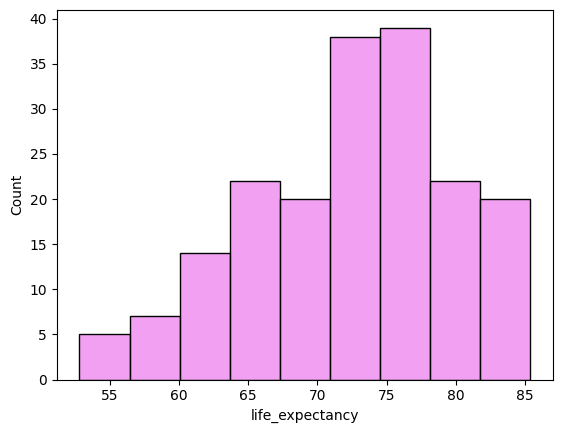

In [ ]:
sns.histplot(x = "life_expectancy", data = df_world, color = "violet");

# Distribución sesgada a la derecha.
# La media está más afectada por outliers que fertility_rate

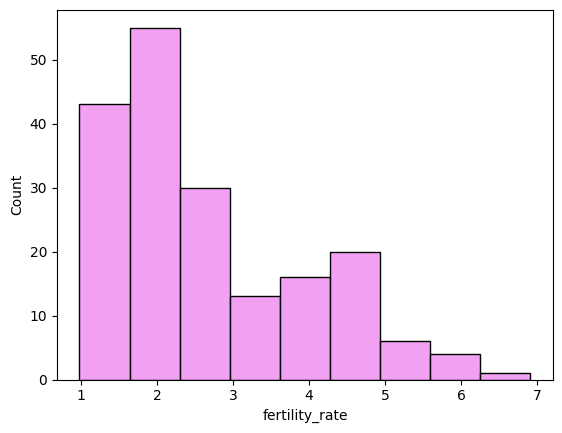

In [ ]:
sns.histplot(x = "fertility_rate", data = df_world, color = "violet");

# Distribución sesgada a la izquierda.
# La mediana es más robusta. Media y mediana tienen valores más cercanos que life_expectancy.

3. Población total vs. densidad de población
Variables: population, density

Calcula para ambas:
- Media, mediana, desviación estándar.
- Dibuja un histograma de population y otro de density.

Interpreta:
- ¿Cuál de las dos variables parece más concentrada (menos dispersa)?
- ¿Por qué no es lo mismo analizar population que density cuando comparamos países?

In [ ]:
lista = ["population", "density"]

df_world[lista].agg(["mean", "median", "std"]).T

# A pesar de que "population" es necesario para calcular "density", no es lo mismo analizar una que otra, dependerá de tu intención con el análisis de datos.

,mean,median,std
population,333.542718,215.056,296.467504
density,134.504533,83.000,157.306774


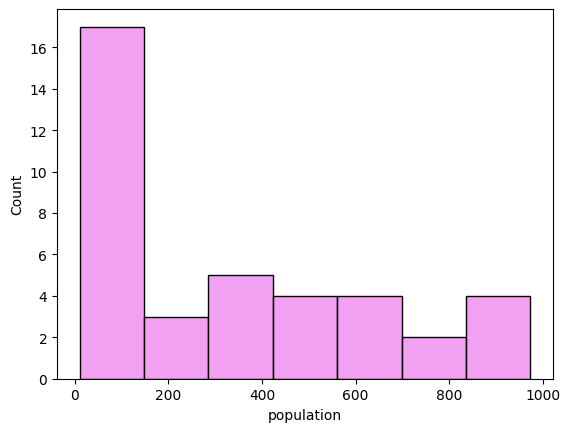

In [ ]:
sns.histplot(x = "population", data = df_world, color = "violet");

# "population" está más concentrada. Aunque tiene outliers al inicio del conjunto de datos, representan una menor cantidad respecto a "density".

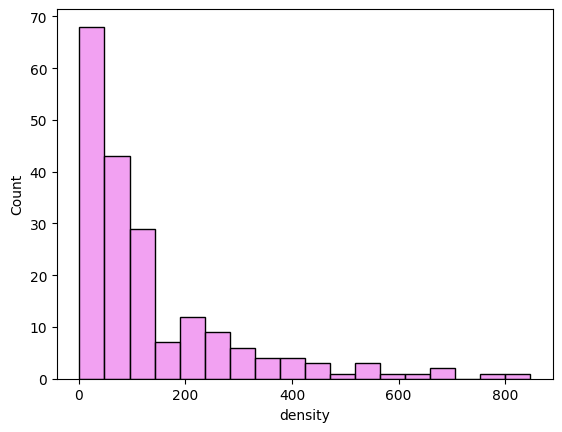

In [15]:
sns.histplot(x = "density", data = df_world, color = "violet");


4. Comparando grupos con medias y medianas: países más y menos ricos
Variable base: gdp

Calcula la mediana de gdp en el conjunto de datos.

Crea dos grupos de países:
- grupo_bajo_gdp: países con gdp por debajo (o igual) de la mediana.
- grupo_alto_gdp: países con gdp por encima de la mediana.

Para cada grupo, calcula la media y la mediana de:
- life_expectancy
- infant_mortality

Interpreta:
- ¿En qué grupo la esperanza de vida es mayor, de media?
- ¿En qué grupo la mortalidad infantil es más alta?
- En lenguaje de políticas públicas, ¿qué conclusión preliminar podrías sacar de esta comparación simple?

In [21]:
mediana = df_world["gdp"].median()

grupo_bajo_gdp = df_world[df_world["gdp"] <= mediana]
grupo_alto_gdp = df_world[df_world["gdp"] > mediana]

df_bajo = grupo_bajo_gdp[["life_expectancy", "infant_mortality"]].agg(["mean", "median"]).T
df_alto =  grupo_alto_gdp[["life_expectancy", "infant_mortality"]].agg(["mean", "median"]).T


In [ ]:
df_bajo

# La mortalidad infantil es menor en los países cuyo gdp es inferior a la mediana del gdp

,mean,median
life_expectancy,68.874725,69.6
infant_mortality,28.877419,25.1


In [ ]:
df_alto

# La esperanza de vida es mayor en los países cuyo gdp es superior a la mediana del gdp

,mean,median
life_expectancy,75.507292,76.50
infant_mortality,14.023958,7.05


Analizando ambos, encontramos que en el grupo bajo, la mortalidad infantil es el doble respecto al grupo alto y, la esperanza de vida es inferior respecto al grupo alto. Concluimos que el grupo bajo tienen una esperanza de vida inferior y mayor tasa de mortalidad infantil.
Detectamos outliers en el grupo bajo, ya que la media está sesgada a la derecha.
En el grupo alto, la media se ve afectada por outliers que sesgan nuestros datos a la izquierda.

5. Bonus: variabilidad de la fuerza laboral
Variable: population_labor_force_participation

Calcula:
- Media
- Mediana
- Desviación estándar
- Percentiles 25, 50 y 75.

Interpreta:
- ¿Está la participación en la fuerza laboral muy concentrada alrededor de un valor, o es bastante dispersa?
- ¿Qué te indica la comparación entre los percentiles 25 y 75 sobre las diferencias entre países?

In [25]:
df_world["population_labor_force_participation"].agg(["mean", "median", "std"]).T

mean      62.738068
median    62.450000
std       10.502907
Name: population_labor_force_participation, dtype: float64

In [27]:
Q1 = df_world["population_labor_force_participation"].quantile(0.25)
Q2 = df_world["population_labor_force_participation"].quantile(0.50)
Q3 = df_world["population_labor_force_participation"].quantile(0.75)

print("Q1: ", Q1)
print("Q2: ", Q2)
print("Q3: ", Q3)

Q1:  56.150000000000006
Q2:  62.45
Q3:  69.5


La media y mediana tienen valores similares. La participación en la fuerza laboral está concretada alrededor de un valor.
Si comparamos los percentiles 25 y 75, observamos que los valores son moderados, no muestran grandes diferencias entre países.

In [28]:
df_world["population_labor_force_participation"].describe().T

count    176.000000
mean      62.738068
std       10.502907
min       38.000000
25%       56.150000
50%       62.450000
75%       69.500000
max       86.800000
Name: population_labor_force_participation, dtype: float64

<Axes: ylabel='population_labor_force_participation'>

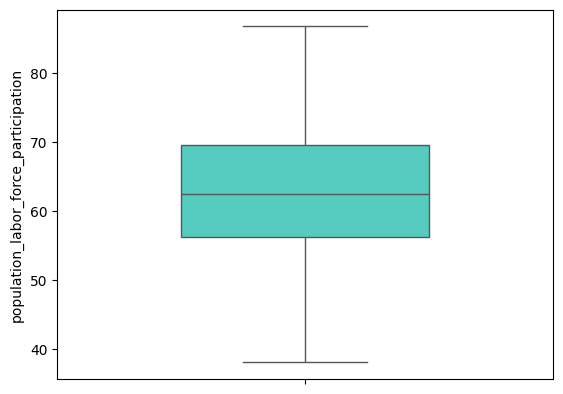

In [ ]:
sns.boxplot(y = "population_labor_force_participation", 
            data = df_world, 
            width = 0.5, 
            color = "turquoise")